PIPELINE DE OTIMIZAÇÃO PARA MODELO SUBSTITUTO DE HIDRÓLISE ENZIMÁTICA
--------------------------------------------------------------------------------

Teste da função de simulação (resultados para 150 g/L sólidos, 0.175 g/L enzima):
Glicose: 63.18 g/L
Xilose: 8.82 g/L
Celobiose: 1.36 g/L


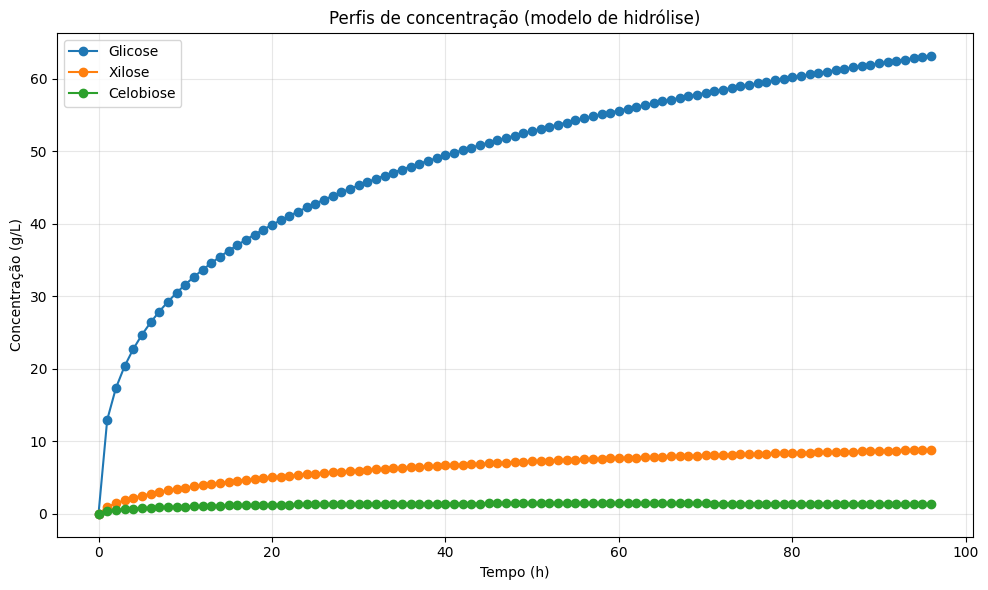

: 

In [ ]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÕES E DEFINIÇÃO DA FUNÇÃO DE SIMULAÇÃO
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import qmc
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("PIPELINE DE OTIMIZAÇÃO PARA MODELO SUBSTITUTO DE HIDRÓLISE ENZIMÁTICA")
print("-" * 80)

# ==============================================================================
# DEFINIÇÃO DA FUNÇÃO DE SIMULAÇÃO COM BASE NO NOTEBOOK HYDROLYSIS.IPYNB
# ==============================================================================

def run_hydrolysis_simulation(solids_loading, enzyme_loading, cellulose_fraction=0.66, 
                             hemicellulose_fraction=0.083, lignin_fraction=0.257, 
                             t_final=96.0, alfa=1.0, return_timeseries=False):
    """
    Função que simula o processo de hidrólise enzimática baseada no modelo de Angarita et al. 2015.
    
    Parâmetros:
    -----------
    solids_loading : float
        Carregamento de sólidos (g/L)
    enzyme_loading : float
        Concentração total de enzima (g/L)
    cellulose_fraction : float
        Fração de celulose na biomassa
    hemicellulose_fraction : float
        Fração de hemicelulose na biomassa
    lignin_fraction : float
        Fração de lignina na biomassa
    t_final : float
        Tempo final de simulação em horas
    alfa : float
        Fator de resistência
    return_timeseries : bool
        Se True, retorna todas as séries temporais; se False, retorna apenas os valores finais
    
    Retorno:
    --------
    Se return_timeseries=False:
        dict: Dicionário com concentrações finais de glicose, xilose e celobiose
    Se return_timeseries=True:
        tuple: (tempos, dict_concentracoes) com séries temporais completas
    """
    # Variáveis operacionais
    S0 = solids_loading      # Carregamento de sólidos (g/L)
    E_T = enzyme_loading     # Concentração total de enzima (g/L)
    
    # Parâmetros cinéticos (Angarita et al. 2015)
    k_1r = 0.177              # Taxa de reação r1 (h⁻¹)
    k_2r = 8.81               # Taxa de reação r2 (h⁻¹)
    k_3r = 201.0              # Taxa de reação r3 (h⁻¹)
    k_4r = 16.34              # Taxa de reação r4 (h⁻¹)

    # Constantes de inibição - Reação 1
    k_11G2 = 0.402            # Inibição por celobiose (g/L)
    k_11G = 2.71              # Inibição por glicose (g/L)
    k_11X = 2.15              # Inibição por xilose (g/L)

    # Constantes de inibição - Reação 2
    k_21G2 = 119.6            # Inibição por celobiose (g/L)
    k_21G = 4.69              # Inibição por glicose (g/L)
    k_21X = 0.095             # Inibição por xilose (g/L)

    # Constantes de Michaelis-Menten - Reação 3
    k_3M = 26.6               # Constante de Michaelis (g/L)
    k_31G = 11.06             # Inibição por glicose (g/L)
    k_31X = 1.023             # Inibição por xilose (g/L)

    # Constantes de inibição - Reação 4
    k_41G2 = 16.25            # Inibição por celobiose (g/L)
    k_41G = 4.0               # Inibição por glicose (g/L)
    k_41X = 154.0             # Inibição por xilose (g/L)

    # Parâmetros de adsorção enzimática
    k_ad = 7.16               # Constante de adsorção
    E_max = 8.32/1000         # Capacidade máxima de adsorção (g/L)
    
    # Função para calcular equilíbrio enzimático
    def calcular_enzima_equilibrio(E_T, S, E_max, k_ad):
        """Calcula enzima livre e adsorvida em equilíbrio"""
        def equation(E_F):
            E_B = E_T - E_F
            return E_max * k_ad * E_F / (1 + k_ad * E_F) - E_B / S
        
        E_F = fsolve(equation, 0.1)[0]
        E_B = E_T - E_F
        return E_F, E_B
    
    # Sistema de equações diferenciais
    def modelo_hidrolise(t, y):
        """
        Sistema de ODEs para hidrólise enzimática
        
        Variáveis de estado:
        y[0] = C    - Celulose (g/L)
        y[1] = G2   - Celobiose (g/L)
        y[2] = G    - Glicose (g/L)
        y[3] = H    - Hemicelulose (g/L)
        y[4] = X    - Xilose (g/L)
        y[5] = S    - Biomassa total (g/L)
        y[6] = E_B  - Enzima adsorvida (g/L)
        y[7] = E_F  - Enzima livre (g/L)
        """
        
        C, G2, G, H, X, S, E_B, E_F = y
        
        # Evitar divisão por zero
        S = max(S, 1e-6)
        
        # Fator de resistência
        R_S = alfa * S / S0
        
        # Concentrações de enzima específica
        Ebc = E_B * C / S     # Enzima específica para celulose
        Ebh = E_B * H / S     # Enzima específica para hemicelulose
        
        # Taxas de reação
        r1 = k_1r * Ebc * R_S * C / (1 + G2/k_11G2 + G/k_11G + X/k_11X)
        r2 = k_2r * Ebc * R_S * C / (1 + G2/k_21G2 + G/k_21G + X/k_21X)
        r3 = k_3r * E_F * G2 / (k_3M * (1 + G/k_31G + X/k_31X) + G2)
        r4 = k_4r * Ebh * R_S * H / (1 + G2/k_41G2 + G/k_41G + X/k_41X)
        
        # Equações diferenciais
        dCdt = -r1 - r2                 # Celulose
        dG2dt = 1.056 * r1 - r3         # Celobiose
        dGdt = 1.111 * r2 + 1.053 * r3  # Glicose
        dHdt = -r4                      # Hemicelulose
        dXdt = 1.136 * r4               # Xilose
        dSdt = -r1 - r2 - r4            # Biomassa
        
        # Enzimas (equações algébricas - derivadas = 0)
        dE_Bdt = 0
        dE_Fdt = 0
        
        return [dCdt, dG2dt, dGdt, dHdt, dXdt, dSdt, dE_Bdt, dE_Fdt]
    
    # Calcular enzimas em equilíbrio inicial
    E_F_inicial, E_B_inicial = calcular_enzima_equilibrio(E_T, S0, E_max, k_ad)
    
    # Condições iniciais
    y0 = [
        S0 * cellulose_fraction,     # Celulose inicial
        0.0,                         # Celobiose inicial
        0.0,                         # Glicose inicial
        S0 * hemicellulose_fraction, # Hemicelulose inicial
        0.0,                         # Xilose inicial
        S0,                          # Biomassa inicial
        E_B_inicial,                 # Enzima adsorvida inicial
        E_F_inicial                  # Enzima livre inicial
    ]
    
    # Pontos de tempo para avaliação
    if return_timeseries:
        t_pontos = np.linspace(0, t_final, int(t_final) + 1)  # Um ponto por hora
    else:
        t_pontos = np.array([0, t_final])  # Apenas tempos inicial e final
    
    # Resolver sistema de ODEs
    sol = solve_ivp(modelo_hidrolise, [0, t_final], y0, t_eval=t_pontos, method='LSODA', rtol=1e-8)

    if not sol.success:
        raise RuntimeError(f"Falha na integração do ODE solver: {sol.message}")

    # Extrair resultados
    t_sim = sol.t
    C_sim = sol.y[0]     # Celulose
    G2_sim = sol.y[1]    # Celobiose
    G_sim = sol.y[2]     # Glicose
    H_sim = sol.y[3]     # Hemicelulose
    X_sim = sol.y[4]     # Xilose
    S_sim = sol.y[5]     # Biomassa
    EB_sim = sol.y[6]    # Enzima adsorvida
    EF_sim = sol.y[7]    # Enzima livre
    
    if return_timeseries:
        # Retornar as séries temporais completas
        return t_sim, {
            'cellulose': C_sim,
            'cellobiose': G2_sim,
            'glucose': G_sim,
            'hemicellulose': H_sim,
            'xylose': X_sim,
            'biomass': S_sim,
            'adsorbed_enzyme': EB_sim,
            'free_enzyme': EF_sim
        }
    else:
        # Retornar apenas os valores finais (índice -1)
        return {
            'glucose': G_sim[-1],
            'xylose': X_sim[-1],
            'cellobiose': G2_sim[-1]
        }

# Verificar a função com um teste rápido
resultado_teste = run_hydrolysis_simulation(150, 0.175)
print("\nTeste da função de simulação (resultados para 150 g/L sólidos, 0.175 g/L enzima):")
print(f"Glicose: {resultado_teste['glucose']:.2f} g/L")
print(f"Xilose: {resultado_teste['xylose']:.2f} g/L")
print(f"Celobiose: {resultado_teste['cellobiose']:.2f} g/L")

# Executar teste com visualização (agora em gráfico)
tempos, concentracoes = run_hydrolysis_simulation(150.0, 0.175, return_timeseries=True)
plt.figure(figsize=(10, 6))
series = {'Glicose': 'glucose', 'Xilose': 'xylose', 'Celobiose': 'cellobiose'}
for label, key in series.items():
    plt.plot(tempos, concentracoes[key], marker='o', linewidth=1.5, label=label)
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração (g/L)')
plt.title('Perfis de concentração (modelo de hidrólise)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()